<a href="https://colab.research.google.com/github/naruto1265/CodSoft-Customer-Churn-Prediction/blob/main/MOVIE_GENRE_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score


In [ ]:
# 1. LOAD DATA
# The separator is ' ::: ' as seen in your description.txt
train_path = '/content/sample_data/train_data.txt'
test_path = '/content/sample_data/test_data.txt'
test_solution_path = '/content/sample_data/test_data_solution.txt'
train_data = pd.read_csv(train_path, sep=' ::: ', engine='python',
                         names=['ID', 'TITLE', 'GENRE', 'DESCRIPTION'])
test_data = pd.read_csv(test_path, sep=' ::: ', engine='python',
                        names=['ID', 'TITLE', 'DESCRIPTION'])
test_solution = pd.read_csv(test_solution_path, sep=' ::: ', engine='python',
                             names=['ID', 'TITLE', 'GENRE', 'DESCRIPTION'])

In [ ]:
# 2. DATA PREPROCESSING
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text


In [ ]:
print("Cleaning data...")
train_data['DESCRIPTION_CLEAN'] = train_data['DESCRIPTION'].apply(clean_text)
test_data['DESCRIPTION_CLEAN'] = test_data['DESCRIPTION'].apply(clean_text)



Cleaning data...


In [ ]:
# 3. FEATURE EXTRACTION (TF-IDF)
# Converting text into numerical vectors
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train = tfidf.fit_transform(train_data['DESCRIPTION_CLEAN'])
y_train = train_data['GENRE']

X_test = tfidf.transform(test_data['DESCRIPTION_CLEAN'])
y_test = test_solution['GENRE']


In [ ]:

# 4. MODEL TRAINING
# Multinomial Naive Bayes is excellent for text classification
model = MultinomialNB()
model.fit(X_train, y_train)



MultinomialNB()

In [ ]:
# 5. EVALUATION
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.52


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
               precision    recall  f1-score   support

      action       0.56      0.11      0.18      1314
       adult       0.51      0.06      0.11       590
   adventure       0.74      0.08      0.14       775
   animation       0.00      0.00      0.00       498
   biography       0.00      0.00      0.00       264
      comedy       0.52      0.43      0.47      7446
       crime       0.00      0.00      0.00       505
 documentary       0.57      0.87      0.69     13096
       drama       0.46      0.83      0.59     13612
      family       0.67      0.00      0.01       783
     fantasy       0.00      0.00      0.00       322
   game-show       0.97      0.33      0.49       193
     history       0.00      0.00      0.00       243
      horror       0.70      0.36      0.48      2204
       music       0.76      0.15      0.25       731
     musical       0.00      0.00      0.00       276
     mystery       0.00      0.00      0.00       318
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


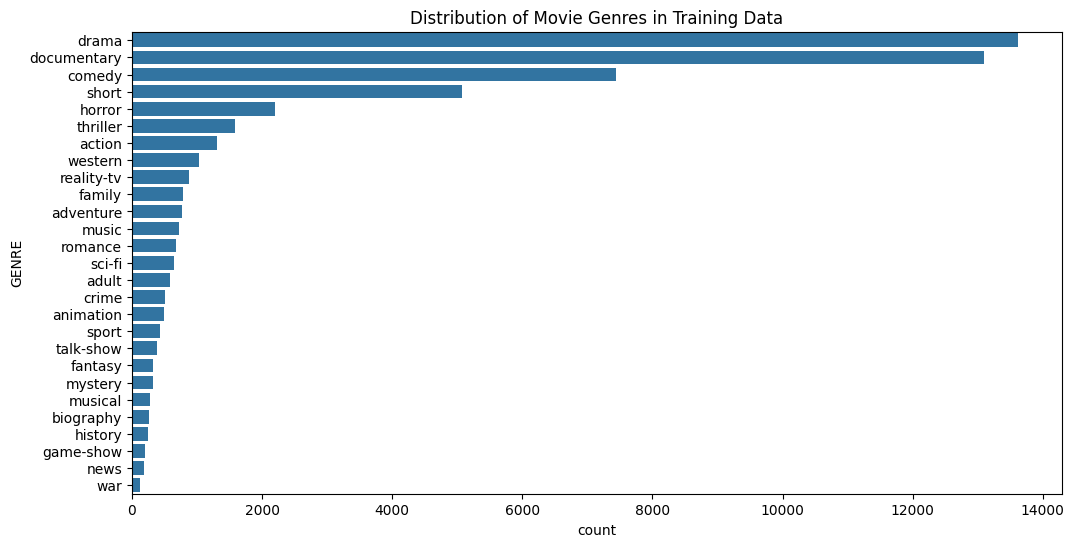

In [ ]:
# 6. VISUALIZATION OF GENRE DISTRIBUTION
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, y='GENRE', order=train_data['GENRE'].value_counts().index)
plt.title('Distribution of Movie Genres in Training Data')
plt.show()